In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aneesh10/cricket-shot-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/aneesh10/cricket-shot-dataset


In [2]:
import pandas as pd
import numpy as np
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import time
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
sns.set_style('darkgrid')
import shutil
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import time
from tqdm import tqdm
from sklearn.metrics import f1_score
from IPython.display import YouTubeVideo
import sys
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")
pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199
print ('Modules loaded')

Modules loaded


In [3]:
# Function to build DataFrames & compute image metadata
def make_dataframes(sdir):
    filepaths = []
    labels = []
    classlist = sorted(os.listdir(sdir))

    for klass in classlist:
        classpath = os.path.join(sdir, klass)
        if os.path.isdir(classpath):
            flist = sorted(os.listdir(classpath))
            desc = f'{klass:25s}'
            for f in tqdm(flist, ncols=130, desc=desc, unit='files', colour='blue'):
                fpath = os.path.join(classpath, f)
                filepaths.append(fpath)
                labels.append(klass)

    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')
    df = pd.concat([Fseries, Lseries], axis=1)

    # Train / Validation / Test Splits
    train_df, dummy_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=123, stratify=df['labels'])
    valid_df, test_df = train_test_split(dummy_df, train_size=0.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])

    classes = sorted(train_df['labels'].unique())
    class_count = len(classes)

    # Estimate average image dimensions from a sample
    sample_size = min(50, len(train_df))
    sample_df = train_df.sample(n=sample_size, replace=False)

    ht, wt, count = 0, 0, 0
    for i in range(len(sample_df)):
        fpath = sample_df['filepaths'].iloc[i]
        try:
            img = cv2.imread(fpath)
            if img is not None:
                h, w, _ = img.shape
                wt += w
                ht += h
                count += 1
        except Exception:
            pass

    have = int(ht / count) if count > 0 else 0
    wave = int(wt / count) if count > 0 else 0
    aspect_ratio = have / wave if wave > 0 else 0

    print('Number of classes in processed dataset =', class_count)
    counts = list(train_df['labels'].value_counts())
    print('Maximum files in any class in train_df:', max(counts), '| Minimum files:', min(counts))
    print(f'train_df length: {len(train_df)} | test_df length: {len(test_df)} | valid_df length: {len(valid_df)}')
    print(f'Average image height: {have} | Average image width: {wave} | Aspect ratio (h/w): {aspect_ratio:.2f}')

    return train_df, test_df, valid_df, classes, class_count


# --- DATASET PATH RESOLUTION ---
# Automatically gets path from kagglehub; falls back to local Desktop folder if offline.
try:
    download_path = kagglehub.dataset_download("aneesh10/cricket-shot-dataset")
    if os.path.exists(os.path.join(download_path, "data")):
        sdir = os.path.join(download_path, "data")
    else:
        sdir = download_path
except Exception:
    sdir = r"C:\Users\hp\Desktop\Cricket program\extracted_dataset"

print(f"Loading dataset from: {sdir}\n")

# Run execution
train_df, test_df, valid_df, classes, class_count = make_dataframes(sdir)
print("\nModules loaded successfully & DataFrames created!")

Loading dataset from: /kaggle/input/datasets/aneesh10/cricket-shot-dataset/data



sweep                    : 100%|███████████████████████████████████████████████████████| 1120/1120 [00:00<00:00, 559573.61files/s]


Number of classes in processed dataset = 4
Maximum files in any class in train_df: 882 | Minimum files: 784
train_df length: 3306 | test_df length: 709 | valid_df length: 709
Average image height: 260 | Average image width: 339 | Aspect ratio (h/w): 0.77

Modules loaded successfully & DataFrames created!


In [4]:
def print_in_color(txt_msg,fore_tupple=(0,255,255),back_tupple=(100,100,100)):
    #prints the text_msg in the foreground color specified by fore_tupple with the background specified by back_tupple
    #text_msg is the text, fore_tupple is foregroud color tupple (r,g,b), back_tupple is background tupple (r,g,b)
    # default parameter print in cyan foreground and gray background
    rf,gf,bf=fore_tupple
    rb,gb,bb=back_tupple
    msg='{0}' + txt_msg
    mat='\33[38;2;' + str(rf) +';' + str(gf) + ';' + str(bf) + ';48;2;' + str(rb) + ';' +str(gb) + ';' + str(bb) +'m'
    print(msg .format(mat), flush=True)
    print('\33[0m', flush=True) # returns default print color to back to black
    return

# example default print
msg='test of default colors'
print_in_color(msg)

test of default colors



In [5]:
def trim(df, max_samples, min_samples, column):
    df=df.copy()
    classes=df[column].unique()
    class_count=len(classes)
    length=len(df)
    print ('dataframe initially is of length ',length, ' with ', class_count, ' classes')
    groups=df.groupby(column)
    trimmed_df = pd.DataFrame(columns = df.columns)
    groups=df.groupby(column)
    for label in df[column].unique():
        group=groups.get_group(label)
        count=len(group)
        if count > max_samples:
            sampled_group=group.sample(n=max_samples, random_state=123,axis=0)
            trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
        else:
            if count>=min_samples:
                sampled_group=group
                trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
    print('after trimming, the maximum samples in any class is now ',max_samples, ' and the minimum samples in any class is ', min_samples)
    classes=trimmed_df[column].unique()# return this in case some classes have less than min_samples
    class_count=len(classes) # return this in case some classes have less than min_samples
    length=len(trimmed_df)
    print ('the trimmed dataframe now is of length ',length, ' with ', class_count, ' classes')
    return trimmed_df, classes, class_count

max_samples=784
min_samples=784
column='labels'
train_df, classes, class_count=trim(train_df, max_samples, min_samples, column)

dataframe initially is of length  3306  with  4  classes
after trimming, the maximum samples in any class is now  784  and the minimum samples in any class is  784
the trimmed dataframe now is of length  3136  with  4  classes


In [6]:
def balance(df, n, working_dir, img_size):
    df=df.copy()
    print('Initial length of dataframe is ', len(df))
    aug_dir=os.path.join(working_dir, 'aug')# directory to store augmented images
    if os.path.isdir(aug_dir):# start with an empty directory
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)
    for label in df['labels'].unique():
        dir_path=os.path.join(aug_dir,label)
        os.mkdir(dir_path) # make class directories within aug directory
    # create and store the augmented images
    total=0
    gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,
                                  height_shift_range=.2, zoom_range=.2)
    groups=df.groupby('labels') # group by class
    for label in df['labels'].unique():  # for every class
        group=groups.get_group(label)  # a dataframe holding only rows with the specified label
        sample_count=len(group)   # determine how many samples there are in this class
        if sample_count< n: # if the class has less than target number of images
            aug_img_count=0
            delta=n - sample_count  # number of augmented images to create
            target_dir=os.path.join(aug_dir, label)  # define where to write the images
            msg='{0:40s} for class {1:^30s} creating {2:^5s} augmented images'.format(' ', label, str(delta))
            print(msg, '\r', end='') # prints over on the same line
            aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=img_size,
                                            class_mode=None, batch_size=1, shuffle=False,
                                            save_to_dir=target_dir, save_prefix='aug-', color_mode='rgb',
                                            save_format='jpg')
            while aug_img_count<delta:
                images=next(aug_gen)
                aug_img_count += len(images)
            total +=aug_img_count
    print('Total Augmented images created= ', total)
    # create aug_df and merge with train_df to create composite training set ndf
    aug_fpaths=[]
    aug_labels=[]
    classlist=os.listdir(aug_dir)
    for klass in classlist:
        classpath=os.path.join(aug_dir, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            aug_fpaths.append(fpath)
            aug_labels.append(klass)
    Fseries=pd.Series(aug_fpaths, name='filepaths')
    Lseries=pd.Series(aug_labels, name='labels')
    aug_df=pd.concat([Fseries, Lseries], axis=1)
    df=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
    print('Length of augmented dataframe is now ', len(df))
    return df

In [7]:
working_dir=r'./' # directory to store augmented images
img_size=(240,310)

In [8]:
def make_gens(batch_size, train_df, test_df, valid_df, img_size):
    trgen=ImageDataGenerator()
    t_and_v_gen=ImageDataGenerator()
    msg='{0:70s} for train generator'.format(' ')
    print(msg, '\r', end='') # prints over on the same line
    train_gen=trgen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                       class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)
    msg='{0:70s} for valid generator'.format(' ')
    print(msg, '\r', end='') # prints over on the same line
    valid_gen=t_and_v_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                       class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)
    # for the test_gen we want to calculate the batch size and test steps such that batch_size X test_steps= number of samples in test set
    # this insures that we go through all the sample in the test set exactly once.
    length=len(test_df)
    test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]
    test_steps=int(length/test_batch_size)
    msg='{0:70s} for test generator'.format(' ')
    print(msg, '\r', end='') # prints over on the same line
    test_gen=t_and_v_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                       class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=test_batch_size)
    # from the generator we can get information we will need later
    classes=list(train_gen.class_indices.keys())
    class_indices=list(train_gen.class_indices.values())
    class_count=len(classes)
    labels=test_gen.labels
    print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)
    return train_gen, test_gen, valid_gen, test_batch_size, test_steps, classes


batch_size=20
train_gen, test_gen, valid_gen, test_batch_size, test_steps, classes=make_gens(batch_size, train_df, test_df, valid_df, img_size)

Found 3136 validated image filenames belonging to 4 classes.
Found 709 validated image filenames belonging to 4 classes.
Found 709 validated image filenames belonging to 4 classes.
test batch size:  1   test steps:  709  number of classes :  4


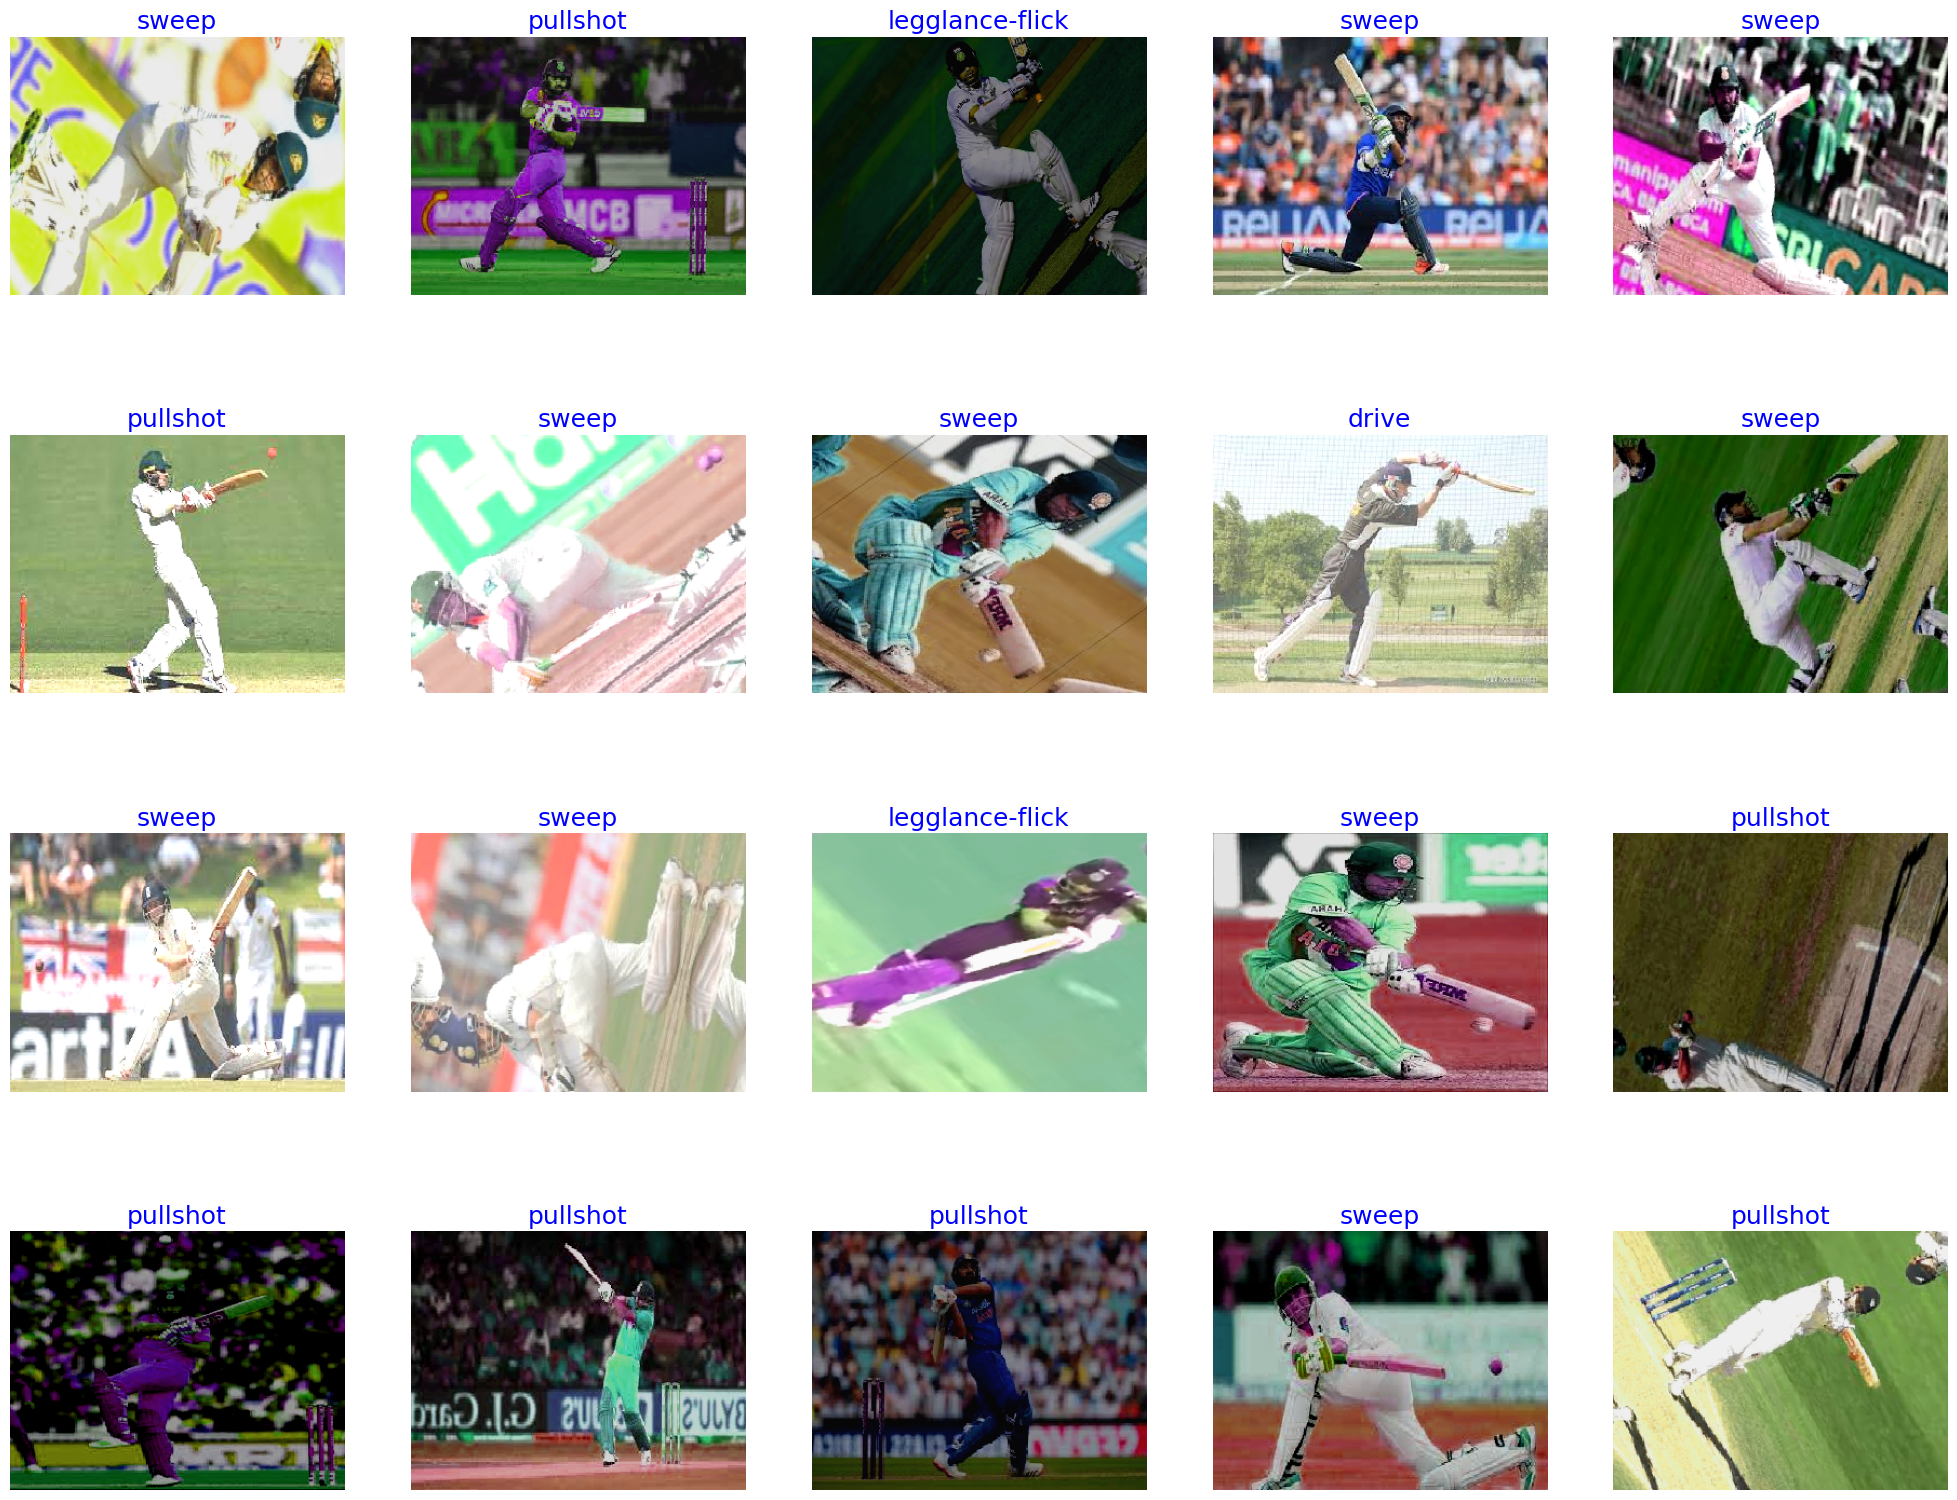

In [9]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())
    images,labels=next(gen) # get a sample batch from the generator
    plt.figure(figsize=(25, 25))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=images[i] /255
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=18)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen )


In [10]:
def make_model(img_size, lr, mod_num=3):  
    img_shape=(img_size[0], img_size[1], 3)
    if mod_num == 0:
        base_model=tf.keras.applications.efficientnet.EfficientNetB0(include_top=False, weights="imagenet",input_shape=img_shape, pooling='max')
        msg='Created EfficientNet B0 model'
    elif mod_num == 3:
        base_model=tf.keras.applications.efficientnet.EfficientNetB3(include_top=False, weights="imagenet",input_shape=img_shape, pooling='max') 
        msg='Created EfficientNet B3 model'
    elif mod_num == 5:
        base_model=tf.keras.applications.efficientnet.EfficientNetB5(include_top=False, weights="imagenet",input_shape=img_shape, pooling='max') 
        msg='Created EfficientNet B5 model'
        
    else:
        base_model=tf.keras.applications.efficientnet.EfficientNetB7(include_top=False, weights="imagenet",input_shape=img_shape, pooling='max')
        msg='Created EfficientNet B7 model'   
   
    base_model.trainable=False
    x=base_model.output
    x=BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
    x = Dense(256, kernel_regularizer = regularizers.l2(l2 = 0.016),activity_regularizer=regularizers.l1(0.006),
                    bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
    x=Dropout(rate=.4, seed=123)(x)       
    output=Dense(class_count, activation='softmax')(x)
    model=Model(inputs=base_model.input, outputs=output)
    model.compile(Adamax(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy']) 
    msg=msg + f' with initial learning rate set to {lr}'
    print_in_color(msg)
    return model

lr=.0001
model=make_model(img_size, lr)

2026-09-21 13:13:10.832295: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Created EfficientNet B3 model with initial learning rate set to 0.0001



In [11]:
class LR_ASK(keras.callbacks.Callback):

    def __init__(self, model, epochs, ask_epoch, dwell=False, factor=.4):
        super(LR_ASK, self).__init__()

        self.ask_epoch = ask_epoch
        self.epochs = epochs
        self.ask = True
        self.lowest_vloss = np.inf
        self.lowest_aloss = np.inf
        self.best_weights = model.get_weights()
        self.best_epoch = 1
        self.plist = []
        self.alist = []
        self.dwell = dwell
        self.factor = factor

    def get_list(self):
        return self.plist, self.alist

    def on_train_begin(self, logs=None):

        if self.ask_epoch == 0:
            print(
                'you set ask_epoch = 0, ask_epoch will be set to 1',
                flush=True
            )
            self.ask_epoch = 1

        if self.ask_epoch >= self.epochs:
            print(
                'ask_epoch >= epochs, will train for',
                self.epochs,
                'epochs',
                flush=True
            )
            self.ask = False

        if self.epochs == 1:
            self.ask = False

        else:
            msg = (
                f'Training will proceed until epoch {self.ask_epoch} '
                f'then you will be asked to'
            )
            print_in_color(msg)

            msg = (
                'enter H to halt training or enter an integer for '
                'how many more epochs to run then be asked again'
            )
            print_in_color(msg)

            if self.dwell:
                msg = 'learning rate will be automatically adjusted during training'
                print_in_color(msg, (0, 255, 0))

        self.start_time = time.time()

    def on_train_end(self, logs=None):

        msg = (
            f'loading model with weights from epoch {self.best_epoch}'
        )
        print_in_color(msg, (0, 255, 255))

        self.model.set_weights(self.best_weights)

        tr_duration = time.time() - self.start_time

        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - (
            (hours * 3600) + (minutes * 60)
        )

        msg = (
            f'training elapsed time was {str(hours)} hours, '
            f'{minutes:4.1f} minutes, {seconds:4.2f} seconds'
        )

        print_in_color(msg)

    def on_epoch_end(self, epoch, logs=None):

        logs = logs or {}

        vloss = logs.get('val_loss')
        aloss = logs.get('loss')

        if vloss is None or aloss is None:
            return

        # Calculate improvement
        if epoch > 0:

            deltav = self.lowest_vloss - vloss

            if self.lowest_vloss != np.inf:
                pimprov = (
                    deltav / self.lowest_vloss
                ) * 100
            else:
                pimprov = 0.0

            self.plist.append(pimprov)

            deltaa = self.lowest_aloss - aloss

            if self.lowest_aloss != np.inf:
                aimprov = (
                    deltaa / self.lowest_aloss
                ) * 100
            else:
                aimprov = 0.0

            self.alist.append(aimprov)

        else:

            pimprov = 0.0
            aimprov = 0.0

        # ------------------------------------------------
        # Validation loss improved
        # ------------------------------------------------
        if vloss < self.lowest_vloss:

            self.lowest_vloss = vloss

            # Save best model weights
            self.best_weights = self.model.get_weights()

            self.best_epoch = epoch + 1

            msg = (
                f'\nvalidation loss of {vloss:7.4f} is '
                f'{pimprov:7.4f}% below lowest loss, '
                f'saving weights from epoch '
                f'{epoch + 1:3d} as best weights'
            )

            print_in_color(msg, (0, 255, 0))

        # ------------------------------------------------
        # Validation loss increased
        # ------------------------------------------------
        else:

            pimprov = abs(pimprov)

            msg = (
                f'\nvalidation loss of {vloss:7.4f} is '
                f'{pimprov:7.4f}% above lowest loss of '
                f'{self.lowest_vloss:7.4f}, keeping weights from '
                f'epoch {self.best_epoch} as best weights'
            )

            print_in_color(msg, (255, 255, 0))

            # Automatically reduce learning rate
            if self.dwell:

                # Current Keras API
                lr = float(
                    self.model.optimizer.learning_rate.numpy()
                )

                new_lr = lr * self.factor

                msg = (
                    f'learning rate was automatically adjusted '
                    f'from {lr:8.6f} to {new_lr:8.6f}, '
                    f'model weights set to best weights'
                )

                print_in_color(msg)

                # Current Keras API
                self.model.optimizer.learning_rate.assign(new_lr)

                # Restore best weights
                self.model.set_weights(self.best_weights)

        # ------------------------------------------------
        # Update lowest training loss
        # ------------------------------------------------
        if aloss < self.lowest_aloss:
            self.lowest_aloss = aloss

        # ------------------------------------------------
        # Ask user whether to continue
        # ------------------------------------------------
        if self.ask:

            if epoch + 1 == self.ask_epoch:

                msg = (
                    '\nEnter H to end training or an integer '
                    'for the number of additional epochs to run '
                    'then ask again'
                )

                print_in_color(msg)

                ans = input()

                # Stop training
                if ans == 'H' or ans == 'h' or ans == '0':

                    msg = (
                        f'you entered {ans}, Training halted on '
                        f'epoch {epoch + 1} due to user input\n'
                    )

                    print_in_color(msg)

                    self.model.stop_training = True

                # Continue training
                else:

                    try:
                        additional_epochs = int(ans)
                    except ValueError:

                        print(
                            'Invalid input. Training will stop.'
                        )

                        self.model.stop_training = True
                        return

                    self.ask_epoch += additional_epochs

                    if self.ask_epoch > self.epochs:

                        print(
                            '\nYou specified maximum epochs of',
                            self.epochs,
                            'cannot train for',
                            self.ask_epoch,
                            flush=True
                        )

                        self.model.stop_training = True

                    else:

                        msg = (
                            f'you entered {ans} Training will '
                            f'continue to epoch {self.ask_epoch}'
                        )

                        print_in_color(msg)

                        # Manually adjust LR if dwell=False
                        if self.dwell == False:

                            lr = float(
                                self.model.optimizer.learning_rate.numpy()
                            )

                            msg = (
                                f'current LR is {lr:8.6f} '
                                f'hit enter to keep this LR or '
                                f'enter a new LR'
                            )

                            print_in_color(msg)

                            ans = input(' ')

                            if ans == '':

                                msg = (
                                    f'keeping current LR of '
                                    f'{lr:7.5f}'
                                )

                                print_in_color(msg)

                            else:

                                try:
                                    new_lr = float(ans)

                                    self.model.optimizer.learning_rate.assign(
                                        new_lr
                                    )

                                    msg = (
                                        f'changing LR to {new_lr}'
                                    )

                                    print_in_color(msg)

                                except ValueError:

                                    print(
                                        'Invalid learning rate. '
                                        'Keeping current LR.'
                                    )

In [12]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Syetem ke saare C++ level warnings ko hide kar deta hai

In [13]:
epochs = 20
ask_epoch = 10

ask = LR_ASK(
    model,
    epochs,
    ask_epoch,
    dwell=True,
    factor=0.4
)

callbacks = [ask]

history = model.fit(
    x=train_gen,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen,
    validation_steps=None,
    shuffle=False,
    initial_epoch=0
)

Training will proceed until epoch 10 then you will be asked to

enter H to halt training or enter an integer for how many more epochs to run then be asked again

learning rate will be automatically adjusted during training

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2940 - loss: 23.7317
validation loss of 22.0541 is  0.0000% below lowest loss, saving weights from epoch   1 as best weights

157/157 ━━━━━━━━━━━━━━━━━━━━ 562s 3s/step - accuracy: 0.3351 - loss: 22.7008 - val_accuracy: 0.4908 - val_loss: 22.0541
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4673 - loss: 20.5531
validation loss of 18.5590 is 15.8477% below lowest loss, saving weights from epoch   2 as best weights

157/157 ━━━━━━━━━━━━━━━━━━━━ 491s 3s/step - accuracy: 0.4923 - loss: 20.0258 - val_accuracy: 0.6685 - val_loss: 18.5590
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5613 - loss: 18.5750
validation loss of 16.6652 is 10.2041% below lowest loss, saving wei

StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

In [ ]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(25,10))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].scatter(Epochs, tloss, s=100, c='red')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs', fontsize=18)
    axes[0].set_ylabel('Loss', fontsize=18)
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].scatter(Epochs, tacc, s=100, c='red')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs', fontsize=18)
    axes[1].set_ylabel('Accuracy', fontsize=18)
    axes[1].legend()
    plt.tight_layout
    plt.show()
    return index_loss

loss_index=tr_plot(history,0)

In [ ]:
def predictor(test_gen):
    y_pred= []
    error_list=[]
    error_pred_list = []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        file=test_gen.filenames[i]
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
            error_class=classes[pred_index]
            t=(file, error_class)
            error_list.append(t)
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    msg=f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}'
    print_in_color(msg, (0,255,255), (100,100,100)) # cyan foreground
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    f1score=f1_score(ytrue, ypred, average='weighted')* 100
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(12, 8))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests, error_list, f1score

errors, tests, error_list, f1score =predictor(test_gen)

In [ ]:
import os

name = 'CRICKET-' + str(len(classes)) + '-(' + str(img_size[0]) + ' X ' + str(img_size[1]) + ')-zeyam'

save_id = f'{name}-{f1score:5.2f}.keras'

model_save_loc = os.path.join('/kaggle/working', save_id)

model.save(model_save_loc)

print(f'Model saved at: {model_save_loc}')

In [ ]:
print("Train class indices:")
print(train_gen.class_indices)

print("\nValidation class indices:")
print(valid_gen.class_indices)

print("\nTest class indices:")
print(test_gen.class_indices)